# Notebook 02b — Active Learning on Picek ViT-B/16-224 Embeddings

**Complete pipeline** — built from scratch on the new Picek embedding, low-budget AL regime.

## Configuration
- **Backbone**: Picek ViT-B/16-224 (frozen, fine-tuned on DF20-Mini)
- **Training target**: Species (179 classes)
- **Evaluation**: Both species and bucket (4 classes), with both hard + soft aggregation
- **AL budget**: 3000 labels (9.2% of training pool = low-budget regime)
- **Init**: 400 (~2 per species stratified)
- **Batch size**: 100
- **Seeds**: 5
- **Strategies**: 6 (random, entropy, margin, coreset, cb_entropy, bald)

## Experimental hypothesis
With a fungi-specialized frozen backbone, we expect:
1. Full-supervision bucket accuracy to jump from 0.75 (CLIP) → 0.85+ (Picek)
2. AL strategy differences to be smaller than with CLIP (strong backbone reduces AL's marginal value)
3. But low budget (3000 labels) may still reveal clear strategy rankings

## Key output
- `results/learning_curves_picekvit.csv` — all learning curves
- Figures and tables for the report


In [1]:
# ==================== IMPORTS ====================
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, recall_score

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f"Device: {DEVICE}")

Device: mps


In [2]:
# ==================== CONFIG ====================
ARTIFACTS_DIR = Path('artifacts')
RESULTS_DIR   = Path('results')
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

BUCKET_ORDER = ['SAFE', 'COOK_FIRST', 'AVOID', 'UNCERTAIN']
N_BUCKETS    = len(BUCKET_ORDER)

# AL config — low budget regime
N_INIT         = 400          # ~2 per species
BATCH_SIZE_AL  = 100
MAX_LABELS     = 3000         # 9.2% of training pool
N_SEEDS        = 5

# MLP config
HIDDEN_DIMS    = (512, 256)
DROPOUT_P      = 0.2
MLP_EPOCHS     = 40
MLP_LR         = 1e-3
MLP_WD         = 1e-4
MLP_BATCH      = 128
MC_SAMPLES     = 20

print(f"Budget: {N_INIT} init → {MAX_LABELS} max, batch {BATCH_SIZE_AL}")
print(f"Rounds per trajectory: {(MAX_LABELS - N_INIT)//BATCH_SIZE_AL + 1}")

Budget: 400 init → 3000 max, batch 100
Rounds per trajectory: 27


## Step 1 — Load Picek Embeddings + Bucket Mapping

In [3]:
# Load new Picek embeddings (from Notebook 01b)
embeddings = np.load(ARTIFACTS_DIR / 'df20m_embeddings_picekvit.npy').astype(np.float32)
metadata   = pd.read_csv(ARTIFACTS_DIR / 'df20m_metadata_picekvit.csv')
buckets_df = pd.read_csv(ARTIFACTS_DIR / 'species_edibility_with_buckets.csv')

# If species_info exists (from old pipeline), use it; otherwise build from current metadata
species_info_path = ARTIFACTS_DIR / 'species_info.csv'
if species_info_path.exists():
    species_info = pd.read_csv(species_info_path)
else:
    species_info = (metadata[['species_id', 'species', 'genus']]
                    .drop_duplicates().sort_values('species_id').reset_index(drop=True))

metadata['species_id']    = metadata['species_id'].astype(int)
metadata['embedding_idx'] = metadata['embedding_idx'].astype(int)

bucket_to_idx = {b: i for i, b in enumerate(BUCKET_ORDER)}
species_name_to_bucket_idx = {
    row['species']: bucket_to_idx[row['bucket']]
    for _, row in buckets_df.iterrows()
}
id_to_species_name = dict(zip(species_info['species_id'], species_info['species']))

N_SPECIES = int(metadata['species_id'].max()) + 1

# Single-level dict lookup (flattened)
species_id_to_bucket_idx = np.array([
    species_name_to_bucket_idx.get(
        id_to_species_name[sid],
        bucket_to_idx['UNCERTAIN']
    )
    for sid in range(N_SPECIES)
])

# Sanity check
print(f"Embedding shape: {embeddings.shape}")
print(f"Species classes: {N_SPECIES}")
print(f"\nspecies_id_to_bucket_idx distribution:")
for i, b in enumerate(BUCKET_ORDER):
    n = (species_id_to_bucket_idx == i).sum()
    print(f"  {b:12s} {n:3d} species")

# Build splits
train_mask = metadata['split'].values == 'train'
test_mask  = metadata['split'].values == 'test'

X_pool = embeddings[train_mask]
y_pool_species = metadata.loc[train_mask, 'species_id'].to_numpy()
X_test = embeddings[test_mask]
y_test_species = metadata.loc[test_mask, 'species_id'].to_numpy()
y_test_bucket  = species_id_to_bucket_idx[y_test_species]
test_genus_arr = metadata.loc[test_mask, 'genus'].to_numpy()

EMBED_DIM = X_pool.shape[1]
print(f"\nPool:  {X_pool.shape[0]:,} x {EMBED_DIM}")
print(f"Test:  {X_test.shape[0]:,}")
print(f"\nTest bucket distribution:")
for i, b in enumerate(BUCKET_ORDER):
    n = (y_test_bucket == i).sum()
    print(f"  {b:12s} {n:5d} ({100*n/len(y_test_bucket):.1f}%)")

Embedding shape: (36361, 768)
Species classes: 179

species_id_to_bucket_idx distribution:
  SAFE          21 species
  COOK_FIRST    37 species
  AVOID         96 species
  UNCERTAIN     25 species

Pool:  32,724 x 768
Test:  3,637

Test bucket distribution:
  SAFE           546 (15.0%)
  COOK_FIRST     764 (21.0%)
  AVOID         2073 (57.0%)
  UNCERTAIN      254 (7.0%)


## Step 2 — MLP with MC Dropout

In [4]:
class MCDropoutMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, n_classes, dropout_p=0.2):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_p))
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_mlp(X, y, n_classes, device=DEVICE, epochs=MLP_EPOCHS,
              lr=MLP_LR, weight_decay=MLP_WD, batch=MLP_BATCH):
    model = MCDropoutMLP(X.shape[1], HIDDEN_DIMS, n_classes, DROPOUT_P).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit = nn.CrossEntropyLoss()

    X_t = torch.from_numpy(X).float().to(device)
    y_t = torch.from_numpy(y).long().to(device)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch, shuffle=True)

    model.train()
    for ep in range(epochs):
        for xb, yb in loader:
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
    return model


@torch.no_grad()
def predict_proba_single(model, X, device=DEVICE, batch=1024):
    model.eval()
    X_t = torch.from_numpy(X).float()
    probs = []
    for i in range(0, len(X_t), batch):
        xb = X_t[i:i+batch].to(device)
        p = F.softmax(model(xb), dim=1)
        probs.append(p.cpu().numpy())
    return np.concatenate(probs, axis=0)


@torch.no_grad()
def predict_proba_mc(model, X, T=MC_SAMPLES, device=DEVICE, batch=1024):
    model.train()   # keep dropout active
    X_t = torch.from_numpy(X).float()
    all_probs = []
    for t in range(T):
        probs_t = []
        for i in range(0, len(X_t), batch):
            xb = X_t[i:i+batch].to(device)
            p = F.softmax(model(xb), dim=1)
            probs_t.append(p.cpu().numpy())
        all_probs.append(np.concatenate(probs_t, axis=0))
    return np.stack(all_probs, axis=0)


def predict_species(model, X, device=DEVICE):
    return predict_proba_single(model, X, device).argmax(axis=1)

## Step 3 — Full-Supervision Ceiling

This establishes the upper bound. Expect significant improvement over CLIP (0.748 hard bucket acc):
- Species accuracy: 0.60-0.72
- Bucket hard accuracy: 0.82-0.88
- Bucket soft accuracy: usually +1-2pt over hard


In [5]:
t0 = time.time()
full_model = train_mlp(X_pool, y_pool_species, N_SPECIES, epochs=MLP_EPOCHS)
print(f"Full-sup training: {time.time()-t0:.1f}s")

# Species-level
y_pred_species = predict_species(full_model, X_test)
full_species_acc = accuracy_score(y_test_species, y_pred_species)
full_species_f1  = f1_score(y_test_species, y_pred_species, average='macro', zero_division=0)

# HARD aggregation
y_pred_bucket_hard = species_id_to_bucket_idx[y_pred_species]
full_bucket_acc_hard = accuracy_score(y_test_bucket, y_pred_bucket_hard)
full_bucket_f1_hard  = f1_score(y_test_bucket, y_pred_bucket_hard, average='macro', zero_division=0)
full_bucket_recalls_hard = recall_score(
    y_test_bucket, y_pred_bucket_hard, average=None, zero_division=0,
    labels=list(range(N_BUCKETS)),
)

# SOFT aggregation
p_species_test = predict_proba_single(full_model, X_test)
p_bucket_test = np.zeros((len(p_species_test), N_BUCKETS), dtype=np.float32)
for bi in range(N_BUCKETS):
    mask = species_id_to_bucket_idx == bi
    p_bucket_test[:, bi] = p_species_test[:, mask].sum(axis=1)
y_pred_bucket_soft = p_bucket_test.argmax(axis=1)
full_bucket_acc_soft = accuracy_score(y_test_bucket, y_pred_bucket_soft)
full_bucket_f1_soft  = f1_score(y_test_bucket, y_pred_bucket_soft, average='macro', zero_division=0)
full_bucket_recalls_soft = recall_score(
    y_test_bucket, y_pred_bucket_soft, average=None, zero_division=0,
    labels=list(range(N_BUCKETS)),
)

# Backward-compat aliases (for plotting cells later)
full_bucket_acc      = full_bucket_acc_hard
full_bucket_f1       = full_bucket_f1_hard
full_bucket_recalls  = full_bucket_recalls_hard

print(f"\n=== Full-supervision ({len(X_pool):,} labels) ===")
print(f"\nSPECIES level (179-way):")
print(f"  Top-1 accuracy: {full_species_acc:.3f}")
print(f"  Macro F1:       {full_species_f1:.3f}")
print(f"  Picek ViT-B/16-224 reported: ~0.720")

print(f"\nBUCKET level - HARD aggregation:")
print(f"  Accuracy: {full_bucket_acc_hard:.3f}")
print(f"  Macro F1: {full_bucket_f1_hard:.3f}")
print(f"  Per-bucket recall:")
for i, b in enumerate(BUCKET_ORDER):
    print(f"    {b:12s} {full_bucket_recalls_hard[i]:.3f}")

print(f"\nBUCKET level - SOFT aggregation:")
print(f"  Accuracy: {full_bucket_acc_soft:.3f}  ({full_bucket_acc_soft-full_bucket_acc_hard:+.3f} vs hard)")
print(f"  Macro F1: {full_bucket_f1_soft:.3f}  ({full_bucket_f1_soft-full_bucket_f1_hard:+.3f} vs hard)")
print(f"  Per-bucket recall:")
for i, b in enumerate(BUCKET_ORDER):
    delta = full_bucket_recalls_soft[i] - full_bucket_recalls_hard[i]
    print(f"    {b:12s} {full_bucket_recalls_soft[i]:.3f}  ({delta:+.3f})")

majority_class = int(np.argmax(np.bincount(y_test_bucket)))
majority_acc = (y_test_bucket == majority_class).mean()
print(f"\nBucket majority baseline: {majority_acc:.3f}")

Full-sup training: 20.9s

=== Full-supervision (32,724 labels) ===

SPECIES level (179-way):
  Top-1 accuracy: 0.591
  Macro F1:       0.466
  Picek ViT-B/16-224 reported: ~0.720

BUCKET level - HARD aggregation:
  Accuracy: 0.817
  Macro F1: 0.728
  Per-bucket recall:
    SAFE         0.758
    COOK_FIRST   0.734
    AVOID        0.900
    UNCERTAIN    0.508

BUCKET level - SOFT aggregation:
  Accuracy: 0.821  (+0.004 vs hard)
  Macro F1: 0.733  (+0.005 vs hard)
  Per-bucket recall:
    SAFE         0.760  (+0.002)
    COOK_FIRST   0.737  (+0.003)
    AVOID        0.906  (+0.006)
    UNCERTAIN    0.512  (+0.004)

Bucket majority baseline: 0.570


## Step 4 — Evaluation Function

In [6]:
def evaluate(model, X_test, y_test_species, y_test_bucket, test_genus_arr,
             species_id_to_bucket_idx, classes_seen):
    p_species = predict_proba_single(model, X_test)
    y_pred_species = p_species.argmax(axis=1)

    sp_acc = accuracy_score(y_test_species, y_pred_species)
    sp_f1  = f1_score(y_test_species, y_pred_species, average='macro', zero_division=0)

    y_pred_bucket_hard = species_id_to_bucket_idx[y_pred_species]
    bk_acc_hard = accuracy_score(y_test_bucket, y_pred_bucket_hard)
    bk_f1_hard  = f1_score(y_test_bucket, y_pred_bucket_hard, average='macro', zero_division=0)
    bucket_recalls_hard = recall_score(
        y_test_bucket, y_pred_bucket_hard, average=None, zero_division=0,
        labels=list(range(N_BUCKETS)),
    )

    p_bucket = np.zeros((len(p_species), N_BUCKETS), dtype=np.float32)
    for bi in range(N_BUCKETS):
        mask = species_id_to_bucket_idx == bi
        p_bucket[:, bi] = p_species[:, mask].sum(axis=1)
    y_pred_bucket_soft = p_bucket.argmax(axis=1)
    bk_acc_soft = accuracy_score(y_test_bucket, y_pred_bucket_soft)
    bk_f1_soft  = f1_score(y_test_bucket, y_pred_bucket_soft, average='macro', zero_division=0)
    bucket_recalls_soft = recall_score(
        y_test_bucket, y_pred_bucket_soft, average=None, zero_division=0,
        labels=list(range(N_BUCKETS)),
    )

    bucket_metrics = {}
    for i in range(N_BUCKETS):
        bucket_metrics[f'recall_{BUCKET_ORDER[i]}']      = bucket_recalls_hard[i]
        bucket_metrics[f'recall_{BUCKET_ORDER[i]}_soft'] = bucket_recalls_soft[i]

    per_genus = {}
    for g in np.unique(test_genus_arr):
        m = test_genus_arr == g
        per_genus[f'acc_{g}'] = accuracy_score(y_test_species[m], y_pred_species[m])

    return {
        'species_acc':     sp_acc,
        'species_f1':      sp_f1,
        'bucket_acc':      bk_acc_hard,
        'bucket_f1':       bk_f1_hard,
        'bucket_acc_soft': bk_acc_soft,
        'bucket_f1_soft':  bk_f1_soft,
        'n_classes_seen':  len(classes_seen),
        **bucket_metrics,
        **per_genus,
    }

## Step 5 — Query Strategies (6 total)

In [7]:
def query_random(X_labeled, y_labeled, X_unlabeled, model, batch_size, rng):
    return rng.choice(len(X_unlabeled), size=batch_size, replace=False)


def query_entropy(X_labeled, y_labeled, X_unlabeled, model, batch_size, rng):
    p = predict_proba_single(model, X_unlabeled)
    entropy = -np.sum(p * np.log(p + 1e-12), axis=1)
    return np.argsort(entropy)[-batch_size:]


def query_margin(X_labeled, y_labeled, X_unlabeled, model, batch_size, rng):
    p = predict_proba_single(model, X_unlabeled)
    p_sorted = np.sort(p, axis=1)
    margin = p_sorted[:, -1] - p_sorted[:, -2]
    return np.argsort(margin)[:batch_size]


def query_coreset(X_labeled, y_labeled, X_unlabeled, model, batch_size, rng):
    sim_to_labeled = X_unlabeled @ X_labeled.T
    min_dist = 1.0 - sim_to_labeled.max(axis=1)
    picked = []
    for _ in range(batch_size):
        idx = int(np.argmax(min_dist))
        picked.append(idx)
        new_sim = X_unlabeled @ X_unlabeled[idx]
        min_dist = np.minimum(min_dist, 1.0 - new_sim)
        min_dist[idx] = -np.inf
    return np.array(picked)


def make_class_balanced_entropy(train_class_freq):
    weights = 1.0 / np.sqrt(train_class_freq + 1)
    weights = weights / weights.sum()
    def _strategy(X_labeled, y_labeled, X_unlabeled, model, batch_size, rng):
        p = predict_proba_single(model, X_unlabeled)
        entropy = -np.sum(p * np.log(p + 1e-12), axis=1)
        pred_class = p.argmax(axis=1)
        tail_weight = weights[pred_class]
        score = entropy * tail_weight
        return np.argsort(score)[-batch_size:]
    return _strategy


def query_bald(X_labeled, y_labeled, X_unlabeled, model, batch_size, rng):
    probs = predict_proba_mc(model, X_unlabeled, T=MC_SAMPLES)
    mean_p = probs.mean(axis=0)
    pred_entropy = -np.sum(mean_p * np.log(mean_p + 1e-12), axis=1)
    per_sample_entropy = -np.sum(probs * np.log(probs + 1e-12), axis=2).mean(axis=0)
    bald_score = pred_entropy - per_sample_entropy
    return np.argsort(bald_score)[-batch_size:]

## Step 6 — Stratified Init + AL Trajectory

In [8]:
def stratified_init(X_pool, y_pool, n_init, n_classes, rng, max_per_class=None):
    target_per_class = max(n_init // n_classes, 1)
    if max_per_class is not None:
        target_per_class = min(target_per_class, max_per_class)
    picked = []
    for c in range(n_classes):
        class_idx = np.where(y_pool == c)[0]
        if len(class_idx) == 0:
            continue
        take = min(target_per_class, len(class_idx))
        picked.extend(rng.choice(class_idx, size=take, replace=False).tolist())
    picked = np.array(picked)
    if len(picked) < n_init:
        remaining = np.setdiff1d(np.arange(len(X_pool)), picked)
        extra_n = min(n_init - len(picked), len(remaining))
        extra = rng.choice(remaining, size=extra_n, replace=False)
        picked = np.concatenate([picked, extra])
    return picked[:n_init]


def run_al_trajectory(X_pool, y_pool_species,
                     X_test, y_test_species, y_test_bucket, test_genus_arr,
                     species_id_to_bucket_idx,
                     strategy_name, strategy_fn,
                     n_init, batch_size, max_labels,
                     seed, n_classes):
    rng = np.random.RandomState(seed)
    torch.manual_seed(seed)

    init_idx = stratified_init(X_pool, y_pool_species, n_init, n_classes, rng)
    labeled_mask = np.zeros(len(X_pool), dtype=bool)
    labeled_mask[init_idx] = True

    history = []
    while labeled_mask.sum() <= max_labels:
        X_labeled = X_pool[labeled_mask]
        y_labeled = y_pool_species[labeled_mask]
        classes_seen = np.unique(y_labeled)

        model = train_mlp(X_labeled, y_labeled, n_classes)
        metrics = evaluate(model, X_test, y_test_species, y_test_bucket, test_genus_arr,
                          species_id_to_bucket_idx, classes_seen)
        metrics['n_labels']  = int(labeled_mask.sum())
        metrics['strategy']  = strategy_name
        metrics['seed']      = seed
        history.append(metrics)

        if labeled_mask.sum() >= max_labels:
            break

        unlabeled_mask = ~labeled_mask
        unlabeled_idx  = np.where(unlabeled_mask)[0]
        X_unlabeled    = X_pool[unlabeled_idx]

        local_picks = strategy_fn(X_labeled, y_labeled, X_unlabeled, model,
                                   batch_size=batch_size, rng=rng)
        global_picks = unlabeled_idx[local_picks]
        labeled_mask[global_picks] = True

    return pd.DataFrame(history)

## Step 7 — Experiment Matrix: 6 Strategies x 5 Seeds

In [9]:
train_class_freq = np.bincount(y_pool_species, minlength=N_SPECIES)
cb_entropy = make_class_balanced_entropy(train_class_freq)

STRATEGIES = {
    'random':     query_random,
    'entropy':    query_entropy,
    'margin':     query_margin,
    'coreset':    query_coreset,
    'cb_entropy': cb_entropy,
    'bald':       query_bald,
}
SEEDS = list(range(N_SEEDS))

print(f"Strategies: {list(STRATEGIES.keys())}")
print(f"Seeds:      {SEEDS}")
print(f"Total runs: {len(STRATEGIES) * len(SEEDS)}")
print(f"Budget:     {N_INIT} -> {MAX_LABELS} (batch {BATCH_SIZE_AL})")
print(f"Rounds:     {(MAX_LABELS - N_INIT)//BATCH_SIZE_AL + 1}")

Strategies: ['random', 'entropy', 'margin', 'coreset', 'cb_entropy', 'bald']
Seeds:      [0, 1, 2, 3, 4]
Total runs: 30
Budget:     400 -> 3000 (batch 100)
Rounds:     27


In [10]:
all_histories = []
log_path = RESULTS_DIR / 'learning_curves_picekvit.csv'

t_start = time.time()
for strategy_name, strategy_fn in STRATEGIES.items():
    for seed in SEEDS:
        t0 = time.time()
        df = run_al_trajectory(
            X_pool, y_pool_species,
            X_test, y_test_species, y_test_bucket, test_genus_arr,
            species_id_to_bucket_idx,
            strategy_name, strategy_fn,
            n_init=N_INIT, batch_size=BATCH_SIZE_AL, max_labels=MAX_LABELS,
            seed=seed, n_classes=N_SPECIES,
        )
        elapsed = time.time() - t0
        final = df.iloc[-1]
        print(f"[{strategy_name:12s} seed={seed}] "
              f"sp={final['species_acc']:.3f}  "
              f"bk_h={final['bucket_acc']:.3f}  "
              f"bk_s={final['bucket_acc_soft']:.3f}  "
              f"UNC={final['recall_UNCERTAIN']:.3f}  "
              f"({elapsed:.0f}s, {len(df)} rds)")
        all_histories.append(df)
        pd.concat(all_histories, ignore_index=True).to_csv(log_path, index=False)

print(f"\nTotal elapsed: {(time.time() - t_start)/60:.1f} minutes")
print(f"Saved: {log_path}")

[random       seed=0] sp=0.467  bk_h=0.748  bk_s=0.751  UNC=0.402  (23s, 27 rds)
[random       seed=1] sp=0.482  bk_h=0.759  bk_s=0.765  UNC=0.433  (21s, 27 rds)
[random       seed=2] sp=0.468  bk_h=0.766  bk_s=0.774  UNC=0.445  (20s, 27 rds)
[random       seed=3] sp=0.484  bk_h=0.765  bk_s=0.771  UNC=0.437  (20s, 27 rds)
[random       seed=4] sp=0.477  bk_h=0.754  bk_s=0.761  UNC=0.484  (21s, 27 rds)
[entropy      seed=0] sp=0.465  bk_h=0.761  bk_s=0.765  UNC=0.374  (24s, 27 rds)
[entropy      seed=1] sp=0.465  bk_h=0.764  bk_s=0.767  UNC=0.465  (22s, 27 rds)
[entropy      seed=2] sp=0.480  bk_h=0.768  bk_s=0.780  UNC=0.445  (21s, 27 rds)
[entropy      seed=3] sp=0.474  bk_h=0.757  bk_s=0.762  UNC=0.445  (26s, 27 rds)
[entropy      seed=4] sp=0.461  bk_h=0.765  bk_s=0.770  UNC=0.449  (26s, 27 rds)
[margin       seed=0] sp=0.462  bk_h=0.761  bk_s=0.771  UNC=0.425  (22s, 27 rds)
[margin       seed=1] sp=0.494  bk_h=0.774  bk_s=0.779  UNC=0.492  (22s, 27 rds)
[margin       seed=2] sp=0.4

## Step 8 — Learning Curves (4 Panels)

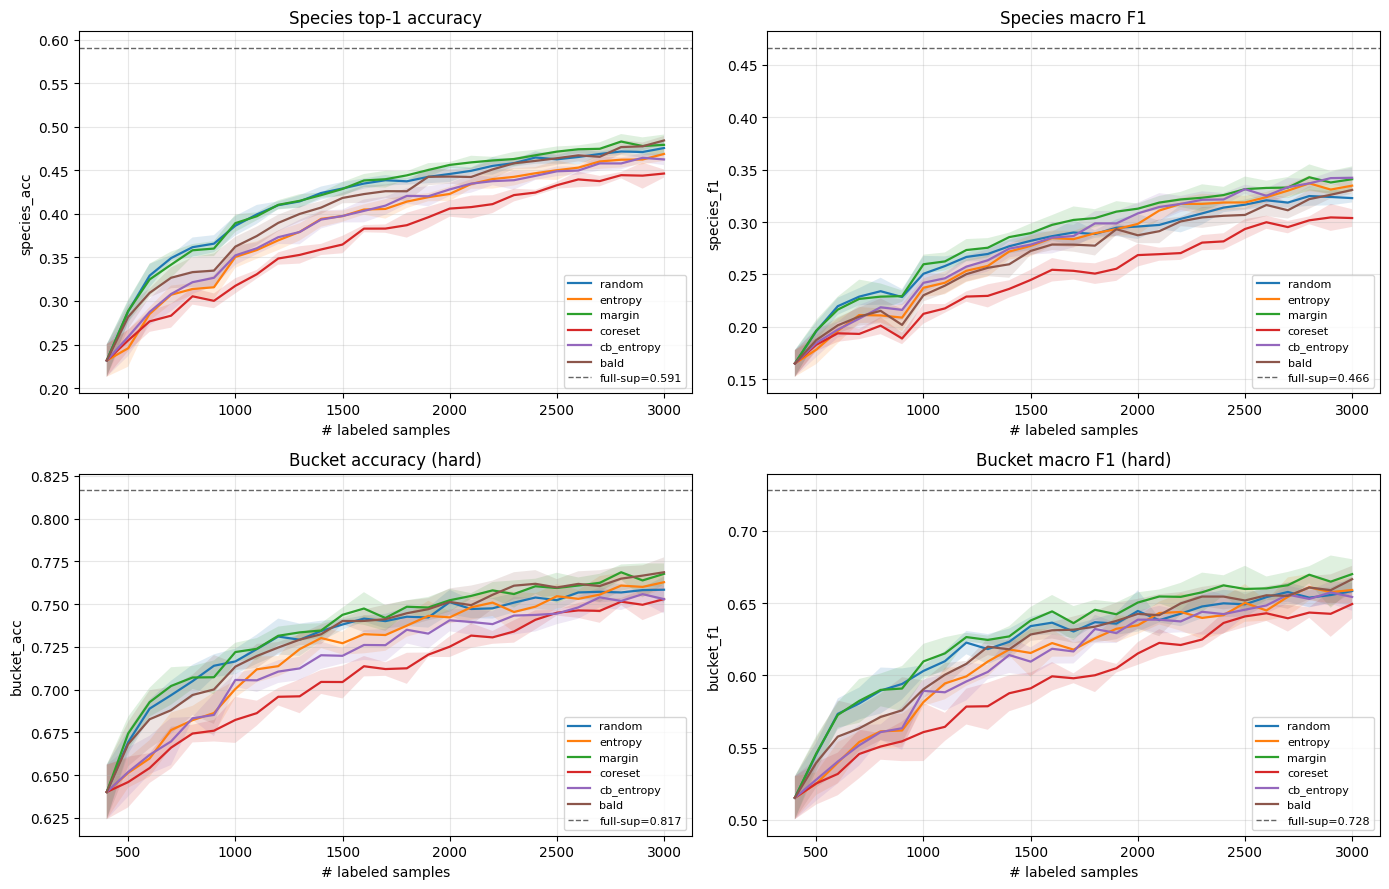

In [11]:
results = pd.concat(all_histories, ignore_index=True)

def plot_curve(results, metric, ax, title, ceiling=None):
    for strategy in STRATEGIES:
        sub = results[results['strategy'] == strategy]
        agg = sub.groupby('n_labels')[metric].agg(['mean', 'std']).reset_index()
        ax.plot(agg['n_labels'], agg['mean'], label=strategy, linewidth=1.6)
        ax.fill_between(agg['n_labels'],
                        agg['mean'] - agg['std'],
                        agg['mean'] + agg['std'],
                        alpha=0.15)
    if ceiling is not None:
        ax.axhline(ceiling, color='black', linestyle='--', linewidth=1,
                   alpha=0.6, label=f'full-sup={ceiling:.3f}')
    ax.set_xlabel('# labeled samples')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_curve(results, 'species_acc', axes[0][0], 'Species top-1 accuracy', full_species_acc)
plot_curve(results, 'species_f1',  axes[0][1], 'Species macro F1',       full_species_f1)
plot_curve(results, 'bucket_acc',  axes[1][0], 'Bucket accuracy (hard)', full_bucket_acc_hard)
plot_curve(results, 'bucket_f1',   axes[1][1], 'Bucket macro F1 (hard)', full_bucket_f1_hard)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'picekvit_learning_curves_hard.png', dpi=120, bbox_inches='tight')
plt.show()

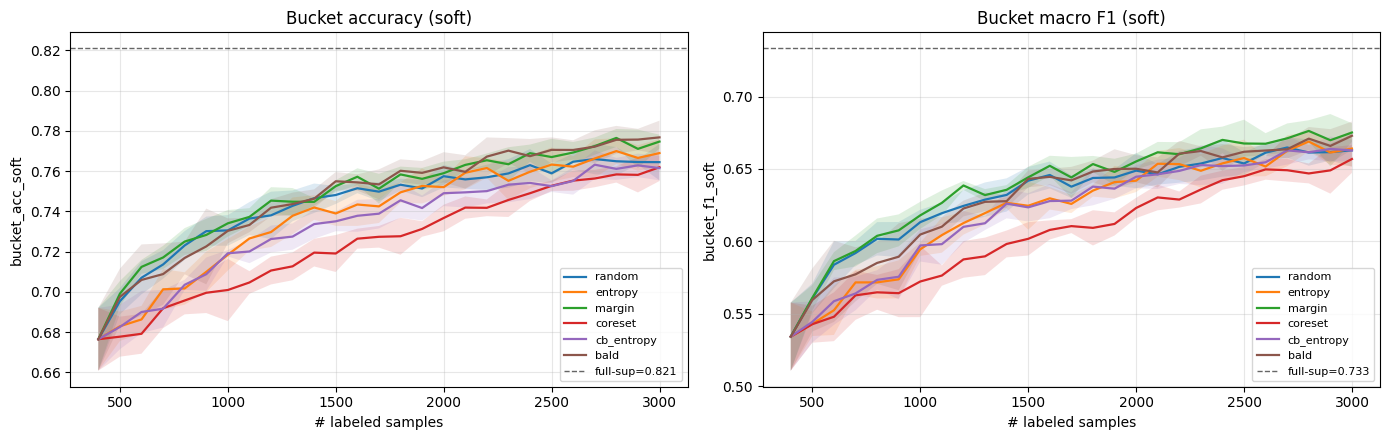

In [12]:
# Soft aggregation learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_curve(results, 'bucket_acc_soft', axes[0], 'Bucket accuracy (soft)', full_bucket_acc_soft)
plot_curve(results, 'bucket_f1_soft',  axes[1], 'Bucket macro F1 (soft)', full_bucket_f1_soft)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'picekvit_learning_curves_soft.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 9 — Per-Bucket Recall Curves

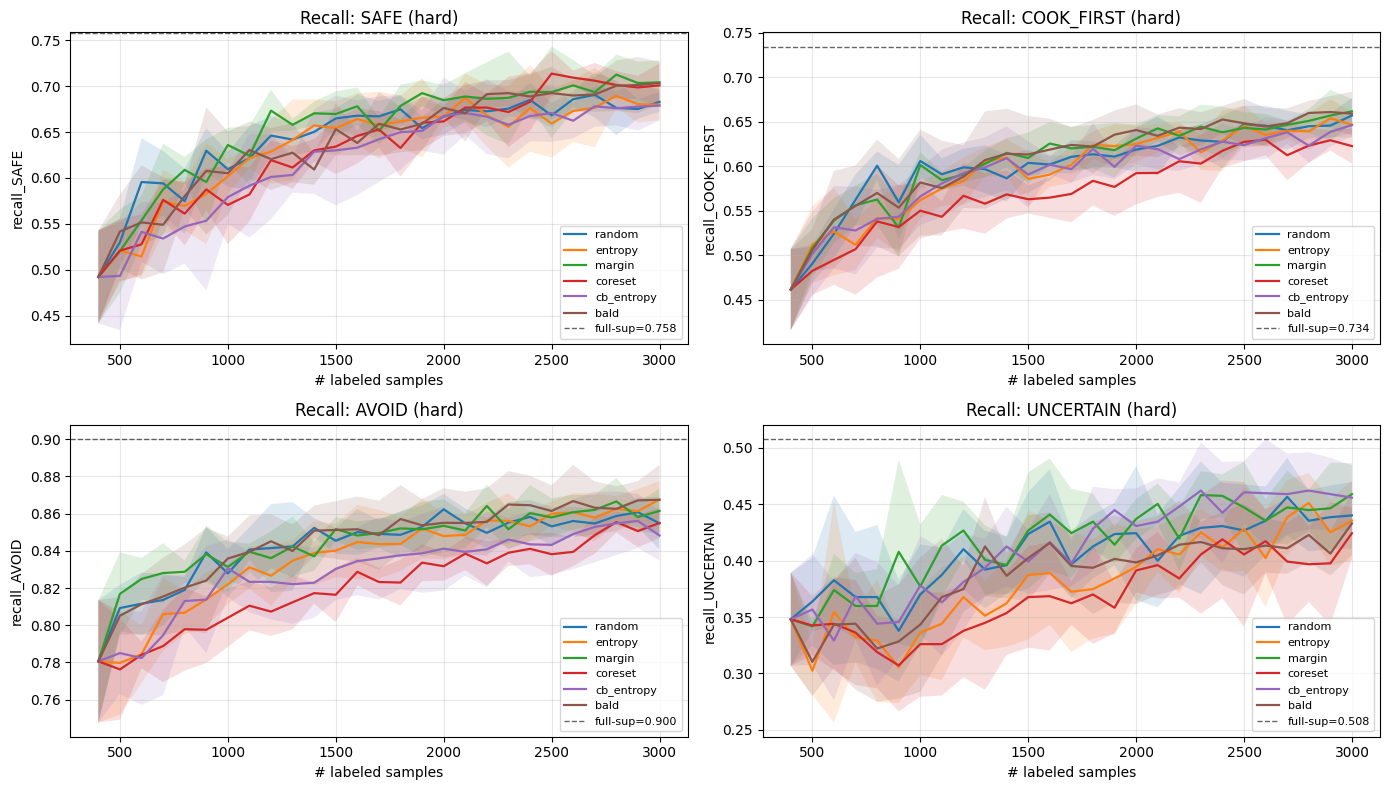

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, b in zip(axes.flat, BUCKET_ORDER):
    metric = f'recall_{b}'
    ceiling = full_bucket_recalls_hard[bucket_to_idx[b]]
    plot_curve(results, metric, ax, f'Recall: {b} (hard)', ceiling=ceiling)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'picekvit_per_bucket_recall.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 10 — Final Summary Table

In [14]:
final_round = results[results['n_labels'] == MAX_LABELS]

# Main summary (hard)
print(f"=== Final at {MAX_LABELS} labels (mean over {N_SEEDS} seeds, HARD aggregation) ===\n")
summary_cols = ['species_acc', 'species_f1', 'bucket_acc', 'bucket_f1'] + \
               [f'recall_{b}' for b in BUCKET_ORDER]
mean_hard = final_round.groupby('strategy')[summary_cols].mean().round(3)
mean_hard.columns = [c.replace('recall_', '').replace('_acc', '_a').replace('_f1', '_f')
                     for c in mean_hard.columns]
print(mean_hard.to_string())

# Soft summary
print(f"\n=== Final at {MAX_LABELS} labels (SOFT aggregation) ===\n")
soft_cols = ['bucket_acc_soft', 'bucket_f1_soft'] + [f'recall_{b}_soft' for b in BUCKET_ORDER]
mean_soft = final_round.groupby('strategy')[soft_cols].mean().round(3)
mean_soft.columns = [c.replace('recall_', '').replace('_acc', '_a').replace('_f1', '_f').replace('_soft', '')
                     for c in mean_soft.columns]
print(mean_soft.to_string())

# Rankings
print(f"\n=== Ranked by SPECIES accuracy ===")
print(final_round.groupby('strategy')['species_acc'].mean().round(3).sort_values(ascending=False).to_string())

print(f"\n=== Ranked by BUCKET accuracy (hard) ===")
print(final_round.groupby('strategy')['bucket_acc'].mean().round(3).sort_values(ascending=False).to_string())

print(f"\n=== Ranked by BUCKET accuracy (soft) ===")
print(final_round.groupby('strategy')['bucket_acc_soft'].mean().round(3).sort_values(ascending=False).to_string())

print(f"\n=== Ranked by BUCKET macro F1 (hard) ===")
print(final_round.groupby('strategy')['bucket_f1'].mean().round(3).sort_values(ascending=False).to_string())

print(f"\n=== Ranked by UNCERTAIN recall (hard) ===")
print(final_round.groupby('strategy')['recall_UNCERTAIN'].mean().round(3).sort_values(ascending=False).to_string())

# Hard vs Soft comparison
print(f"\n=== HARD vs SOFT comparison ===")
compare = pd.DataFrame({
    'bucket_acc_HARD':  final_round.groupby('strategy')['bucket_acc'].mean().round(3),
    'bucket_acc_SOFT':  final_round.groupby('strategy')['bucket_acc_soft'].mean().round(3),
    'bucket_f1_HARD':   final_round.groupby('strategy')['bucket_f1'].mean().round(3),
    'bucket_f1_SOFT':   final_round.groupby('strategy')['bucket_f1_soft'].mean().round(3),
})
compare['acc_delta'] = (compare['bucket_acc_SOFT'] - compare['bucket_acc_HARD']).round(3)
compare['f1_delta']  = (compare['bucket_f1_SOFT']  - compare['bucket_f1_HARD']).round(3)
print(compare.sort_values('bucket_acc_SOFT', ascending=False).to_string())

# Save full summary
final_round.groupby('strategy')[summary_cols + soft_cols].agg(['mean', 'std']).round(3).to_csv(
    RESULTS_DIR / 'picekvit_final_summary.csv'
)
print(f"\nSaved: {RESULTS_DIR}/picekvit_final_summary.csv")

=== Final at 3000 labels (mean over 5 seeds, HARD aggregation) ===

            species_a  species_f  bucket_a  bucket_f   SAFE  COOK_FIRST  AVOID  UNCERTAIN
strategy                                                                                 
bald            0.484      0.331     0.769     0.667  0.703       0.659  0.867      0.433
cb_entropy      0.463      0.342     0.753     0.654  0.679       0.646  0.848      0.456
coreset         0.446      0.304     0.753     0.649  0.701       0.623  0.855      0.424
entropy         0.469      0.335     0.763     0.659  0.680       0.647  0.868      0.435
margin          0.479      0.341     0.768     0.670  0.704       0.662  0.861      0.459
random          0.476      0.323     0.758     0.658  0.683       0.657  0.855      0.440

=== Final at 3000 labels (SOFT aggregation) ===

            bucket_a  bucket_f   SAFE  COOK_FIRST  AVOID  UNCERTAIN
strategy                                                           
bald           0.777     0

## Step 11 — Label Efficiency

How many labels does each strategy need to reach X% of full-sup bucket accuracy?

In [15]:
def labels_to_reach(results, strategy, seed, metric, target):
    sub = results[(results['strategy']==strategy) & (results['seed']==seed)]
    sub = sub.sort_values('n_labels')
    hit = sub[sub[metric] >= target]
    return int(hit.iloc[0]['n_labels']) if len(hit) > 0 else np.nan


# Targets: thresholds relative to full-sup bucket accuracy
targets = [
    ('bucket_acc',      0.80 * full_bucket_acc_hard, '80% of full-sup hard_bucket_acc'),
    ('bucket_acc',      0.90 * full_bucket_acc_hard, '90% of full-sup hard_bucket_acc'),
    ('bucket_acc',      0.95 * full_bucket_acc_hard, '95% of full-sup hard_bucket_acc'),
    ('bucket_acc_soft', 0.95 * full_bucket_acc_soft, '95% of full-sup soft_bucket_acc'),
]

rows = []
for metric, threshold, label in targets:
    row = {'target': label, 'threshold': round(threshold, 3)}
    for strategy in STRATEGIES:
        ls = [labels_to_reach(results, strategy, s, metric, threshold) for s in SEEDS]
        if all(np.isnan(ls)):
            row[strategy] = 'N/A'
        else:
            valid = [l for l in ls if not np.isnan(l)]
            row[strategy] = f"{np.mean(valid):.0f} ({len(valid)}/{len(SEEDS)})"
    rows.append(row)

eff_df = pd.DataFrame(rows)
print("Labels needed to reach target (mean across seeds, with number reached):\n")
print(eff_df.to_string(index=False))
eff_df.to_csv(RESULTS_DIR / 'picekvit_label_efficiency.csv', index=False)

Labels needed to reach target (mean across seeds, with number reached):

                         target  threshold     random    entropy     margin    coreset cb_entropy       bald
80% of full-sup hard_bucket_acc      0.653  480 (5/5)  540 (5/5)  480 (5/5)  600 (5/5)  560 (5/5)  500 (5/5)
90% of full-sup hard_bucket_acc      0.735 1380 (5/5) 1660 (5/5) 1300 (5/5) 2260 (5/5) 1900 (5/5) 1480 (5/5)
95% of full-sup hard_bucket_acc      0.776        N/A        N/A 2900 (1/5)        N/A        N/A 3000 (2/5)
95% of full-sup soft_bucket_acc      0.780        N/A 3000 (1/5) 2800 (1/5)        N/A        N/A 2667 (3/5)


## Step 12 — Per-Genus Analysis (Diagnostic)

In [16]:
genera = sorted(np.unique(test_genus_arr))
acc_cols = [f'acc_{g}' for g in genera]

genus_means = final_round.groupby('strategy')[acc_cols].mean().round(3)
genus_means.columns = genera
print(f"Per-genus SPECIES accuracy at {MAX_LABELS} labels:\n")
print(genus_means.to_string())
genus_means.to_csv(RESULTS_DIR / 'picekvit_per_genus.csv')

Per-genus SPECIES accuracy at 3000 labels:

            Agaricus  Amanita  Boletus  Clitocybe  Mycena  Russula
strategy                                                          
bald           0.430    0.636    0.642      0.524   0.469    0.405
cb_entropy     0.414    0.580    0.570      0.493   0.474    0.385
coreset        0.431    0.557    0.594      0.494   0.473    0.335
entropy        0.428    0.601    0.586      0.521   0.472    0.381
margin         0.435    0.623    0.609      0.514   0.486    0.387
random         0.412    0.628    0.617      0.525   0.489    0.373


## Step 13 — Summary Report

After running everything, the key numbers for the report are:

1. **Full-supervision ceiling** (Step 3 output)
2. **Best AL strategy at 3000 labels** (Step 10 hard ranking)
3. **Label efficiency** — how many labels to reach 95% of full-sup (Step 11)
4. **Hard vs soft aggregation trade-off** (Step 10 comparison table)
5. **Learning curves** (Step 8 figures)

Save all results to `results/picekvit_*.csv` and `results/picekvit_*.png` for the report.
